# MS-SKM by example: decision boundaries on `make_moons`

This notebook introduces the **Multi-Scale Spectral Kernel Machine (MS-SKM)** through a 2-D
problem where we can *see* what each modeling choice does. We use scikit-learn's
`make_moons` --- two interleaving crescents --- because separating them needs an **oblique
interaction** between the two features. A purely additive model cannot draw that boundary, a
kernel can, and a tree ensemble draws it as axis-aligned steps. Plotting the decision boundary
makes each of these visible at a glance.

We treat learning as the construction of a **kernel**, and we build the kernel as a *ladder* in
which each rung lifts exactly one modeling restriction:

| rung | model | frequencies | mixing | kernel |
|---|---|---|---|---|
| 0 | `SpectralGAM`     | fixed (RFF) | none (additive) | none |
| A | `LearnedGAM`      | learned     | none (additive) | none |
| B | `MSSKM(mix=False)`| learned     | block-diagonal  | yes |
| 1 | `MSSKM()`         | learned     | full encoder    | yes |
| 2 | `MSSKM(H=4)`      | learned     | full encoder    | yes (4 banks fused) |

We compare all five rungs against a tuned **CatBoost** on the same data.

In [1]:
import sys, os, warnings
warnings.filterwarnings("ignore")
sys.path.insert(0, os.path.abspath(".."))          # import the skm package from the repo root

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, f1_score, brier_score_loss, log_loss

from skm import SpectralGAM, LearnedGAM, MSSKM
from skm.variational import VariationalMSSKM
from catboost import CatBoostClassifier

SEED = 0
np.random.seed(SEED)

## The data

600 points, two moons, moderate noise (0.20). We hold out 30% for an honest test accuracy.

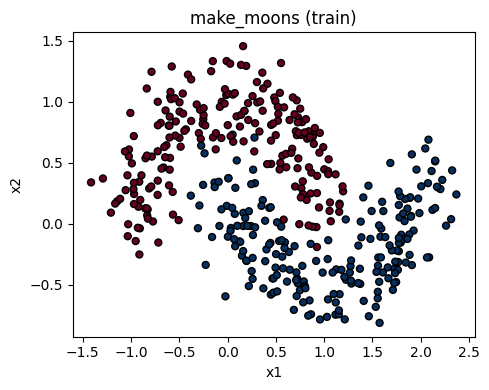

In [2]:
X, y = make_moons(n_samples=600, noise=0.20, random_state=SEED)
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.3, random_state=SEED, stratify=y)

fig, ax = plt.subplots(figsize=(5, 4))
ax.scatter(Xtr[:, 0], Xtr[:, 1], c=ytr, cmap="RdBu", edgecolor="k", s=25)
ax.set_title("make_moons (train)"); ax.set_xlabel("x1"); ax.set_ylabel("x2")
plt.tight_layout(); plt.show()

## A decision-boundary helper

For a 2-D model we evaluate `predict_proba` on a fine grid and shade by the probability of
class 1. The black line is the $p=0.5$ decision boundary; the dots are the held-out test points.
The *shape* of that boundary is the whole story.

In [3]:
def plot_boundary(ax, model, title):
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                         np.linspace(y_min, y_max, 300))
    grid = np.c_[xx.ravel(), yy.ravel()]
    p = model.predict_proba(grid)[:, 1].reshape(xx.shape)
    ax.contourf(xx, yy, p, levels=20, cmap="RdBu", alpha=0.75, vmin=0, vmax=1)
    ax.contour(xx, yy, p, levels=[0.5], colors="k", linewidths=1.5)
    ax.scatter(Xte[:, 0], Xte[:, 1], c=yte, cmap="RdBu", edgecolor="k", s=18)
    ax.set_title(title, fontsize=11)
    ax.set_xticks([]); ax.set_yticks([])

## Fit the ladder and CatBoost

Each model is fit on the same train split. MS-SKM standardizes internally and carves its own
validation fold for early stopping; CatBoost gets a reasonable tuned configuration.

We score with four classification metrics, not just accuracy:
**AUC** (ranking quality, threshold-free), **F1** (balance of precision and recall at the 0.5
threshold), and two proper scoring rules on the predicted probabilities --- **Brier** (mean
squared probability error) and **Log loss** (cross-entropy). For Brier and Log loss, lower is
better; MS-SKM's probabilities are temperature-calibrated on its validation fold.

In [4]:
models = {}
models["rung 0: SpectralGAM\n(fixed RFF, additive)"]   = SpectralGAM(task="classification", seed=SEED, verbose=False).fit(Xtr, ytr)
models["rung A: LearnedGAM\n(learned freq, additive)"] = LearnedGAM(task="classification", seed=SEED, verbose=False).fit(Xtr, ytr)
models["rung B: MSSKM(mix=False)\n(kernel, no mixing)"]= MSSKM(task="classification", mix=False, seed=SEED, verbose=False).fit(Xtr, ytr)
models["rung 1: MSSKM()\n(kernel + mixing)"]           = MSSKM(task="classification", seed=SEED, verbose=False).fit(Xtr, ytr)
models["rung 2: MSSKM(H=4)\n(multi-bank fuse)"]        = MSSKM(task="classification", H=4, seed=SEED, verbose=False).fit(Xtr, ytr)
models["CatBoost\n(gradient-boosted trees)"]           = CatBoostClassifier(iterations=400, depth=6, learning_rate=0.1,
                                                                            random_seed=SEED, verbose=False).fit(Xtr, ytr)

def clf_scores(m):
    proba = m.predict_proba(Xte)
    p1 = proba[:, 1]                                  # P(class 1); classes are 0/1
    pred = m.predict(Xte)
    return {"AUC": roc_auc_score(yte, p1),
            "F1": f1_score(yte, pred),
            "Brier": brier_score_loss(yte, p1),
            "LogLoss": log_loss(yte, proba)}

scores = pd.DataFrame({name.splitlines()[0]: clf_scores(m) for name, m in models.items()}).T
scores = scores[["AUC", "F1", "Brier", "LogLoss"]].round(4)
scores                                                # AUC/F1: higher better; Brier/LogLoss: lower better

,AUC,F1,Brier,LogLoss
rung 0: SpectralGAM,0.9895,0.9385,0.0430,0.1386
rung A: LearnedGAM,0.9907,0.9457,0.0430,0.1537
rung B: MSSKM(mix=False),0.9888,0.9605,0.0358,0.1444
rung 1: MSSKM(),0.9889,0.9605,0.0350,0.1393
rung 2: MSSKM(H=4),0.9896,0.9605,0.0367,0.1423
CatBoost,0.9893,0.9444,0.0467,0.2011


## The boundaries side by side

Read across the rungs:

- **Rungs 0 and A (additive, no kernel).** The boundary is built from a sum of per-feature
  1-D functions, so it cannot bend to follow the moons --- it is forced toward axis-aligned,
  separable contours and mislabels the interleaving tips.
- **Rung B (kernel, no mixing).** Turning the kernel on already produces a curved boundary:
  the radial kernel manufactures interactions even with a block-diagonal embedding, though they
  are axis-aligned.
- **Rung 1 (kernel + mixing).** The encoder mixes the two features, so the interactions become
  oblique and the boundary wraps cleanly around both crescents.
- **Rung 2 (multi-bank).** A convex fuse of bandwidths; on this single-scale problem it looks
  like rung 1.
- **CatBoost.** Accurate, but the boundary is a staircase of axis-aligned splits --- the
  signature of a tree partition.

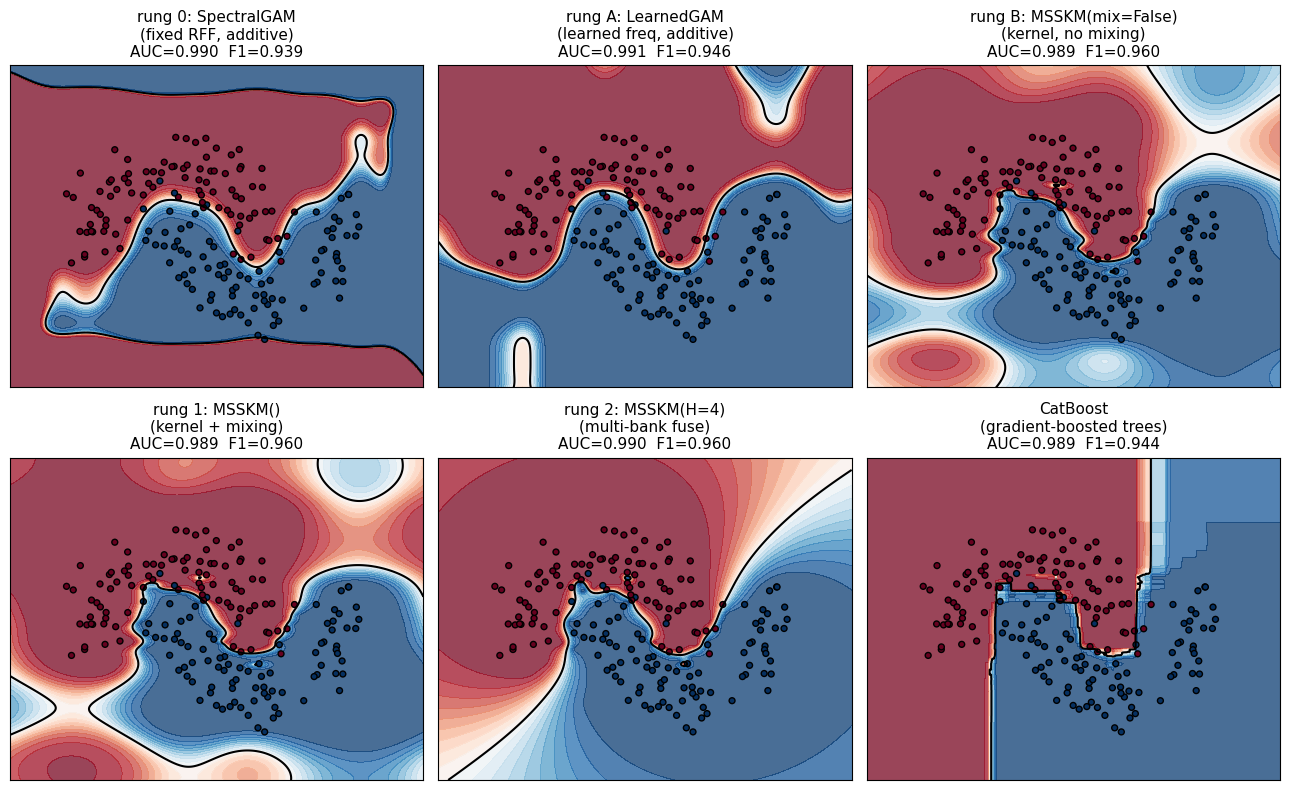

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(13, 8))
for ax, (name, m) in zip(axes.ravel(), models.items()):
    s = clf_scores(m)
    plot_boundary(ax, m, f"{name}\nAUC={s['AUC']:.3f}  F1={s['F1']:.3f}")
plt.tight_layout(); plt.show()

## What the spectral model learned

MS-SKM is inspectable. The **ARD relevance** $s_j$ says how much each feature matters; on
`make_moons` both features are relevant. The additive `SpectralGAM` exposes each per-feature
**shape function** $f_j(x_j)$ directly --- the additive pieces it is restricted to.

MSSKM ARD relevance per feature (s_j): [0.668 0.668]


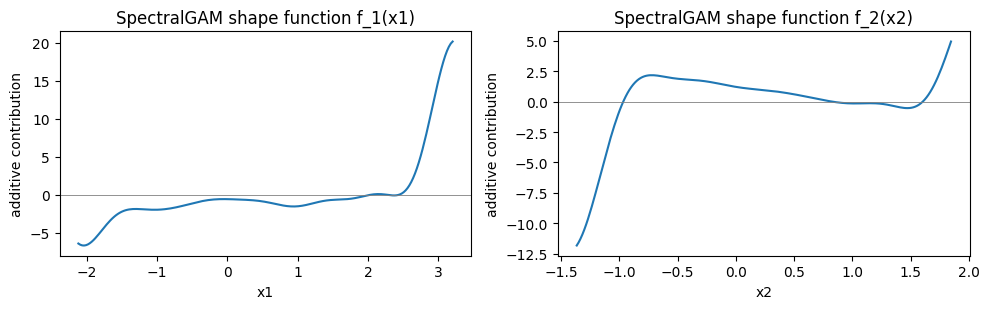

In [6]:
m1 = models["rung 1: MSSKM()\n(kernel + mixing)"]
print("MSSKM ARD relevance per feature (s_j):", np.round(m1.ard_, 3))

gam = models["rung 0: SpectralGAM\n(fixed RFF, additive)"]
fig, axes = plt.subplots(1, 2, figsize=(10, 3.2))
for j, ax in enumerate(axes):
    grid, fj = gam.shape_function(j, n_grid=200)
    ax.plot(grid, fj[:, 1] - fj[:, 0])     # class-1 minus class-0 contribution
    ax.axhline(0, color="gray", lw=0.6)
    ax.set_title(f"SpectralGAM shape function f_{j+1}(x{j+1})")
    ax.set_xlabel(f"x{j+1}"); ax.set_ylabel("additive contribution")
plt.tight_layout(); plt.show()

## Knowing what it does not know: a predictive distribution

Every model above returns a *point* probability. But on a small, noisy problem we also want to
know **where the model is uncertain** --- not the aleatoric coin-flip near $p=0.5$, but the
*epistemic* uncertainty that grows where we have no data.

`VariationalMSSKM` trains the same learned spectral-mixture kernel as a **sparse variational
Gaussian process**: it learns a posterior over the latent function $f$, not just a point estimate.
For classification it uses a **Bernoulli likelihood through a logistic link**, $y\sim\mathrm{Bernoulli}(\sigma(f))$.
The required expectations $\mathbb{E}_{q(f)}[\log\mathrm{Bernoulli}(y\mid\sigma(f))]$ and the
predictive probability $\mathbb{E}_{q(f^\*)}[\sigma(f^\*)]$ have no closed form under a logistic
link, so both are computed by **Gauss--Hermite quadrature** over the Gaussian posterior of $f$.

Beyond the mean probability, `predict_proba_dist` returns the **standard deviation of the predicted
class-1 probability** --- a direct, per-point measure of how unsure the model is about its own
probability.

In [7]:
vmodel = VariationalMSSKM(task="classification", H=2, K=16, n_inducing=200,
                          epochs=250, patience=30, seed=SEED, verbose=False).fit(Xtr, ytr)

s = clf_scores(vmodel)
print("VariationalMSSKM (SVGP, Bernoulli):",
      {k: round(v, 4) for k, v in s.items()})

VariationalMSSKM (SVGP, Bernoulli): {'AUC': 0.9932, 'F1': 0.9556, 'Brier': 0.0347, 'LogLoss': 0.1402}


On the left, the **mean** probability surface --- the same kind of boundary as rung 1, since it is
the same kernel. On the right, the **uncertainty** surface: the standard deviation of the predicted
probability over the plane. It is near zero on top of the two crescents where the data pins the
function down, and it **swells in the gap between the moons and out beyond the data**, exactly the
regions where a point classifier would silently extrapolate. The black line is the $p=0.5$ boundary.

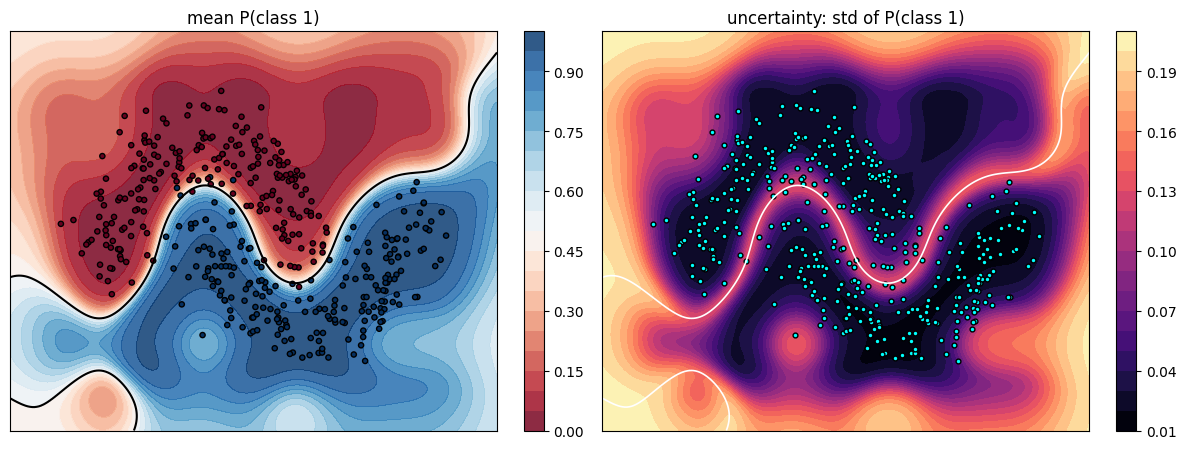

In [8]:
x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 220),
                     np.linspace(y_min, y_max, 220))
grid = np.c_[xx.ravel(), yy.ravel()]

p_mean, p_std = vmodel.predict_proba_dist(grid)        # mean and std of P(class 1)
p_mean = p_mean.reshape(xx.shape); p_std = p_std.reshape(xx.shape)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))

cf0 = axes[0].contourf(xx, yy, p_mean, levels=20, cmap="RdBu", alpha=0.85, vmin=0, vmax=1)
axes[0].contour(xx, yy, p_mean, levels=[0.5], colors="k", linewidths=1.5)
axes[0].scatter(Xtr[:, 0], Xtr[:, 1], c=ytr, cmap="RdBu", edgecolor="k", s=14)
axes[0].set_title("mean P(class 1)"); axes[0].set_xticks([]); axes[0].set_yticks([])
fig.colorbar(cf0, ax=axes[0], fraction=0.046)

cf1 = axes[1].contourf(xx, yy, p_std, levels=20, cmap="magma")
axes[1].contour(xx, yy, p_mean, levels=[0.5], colors="w", linewidths=1.2)
axes[1].scatter(Xtr[:, 0], Xtr[:, 1], c="cyan", edgecolor="k", s=12)
axes[1].set_title("uncertainty: std of P(class 1)"); axes[1].set_xticks([]); axes[1].set_yticks([])
fig.colorbar(cf1, ax=axes[1], fraction=0.046)

plt.tight_layout(); plt.show()

## Takeaways

- The **kernel**, not feature mixing, is what turns interactions on: the additive rungs (0, A)
  give blocky separable boundaries, and the boundary curves the moment the kernel appears (rung B).
- **Mixing** then rotates those interactions from axis-aligned (rung B) to oblique (rung 1),
  which is what `make_moons` needs.
- The metrics agree with the boundaries. **AUC** saturates --- every model ranks the two moons
  well --- but the kernel rungs win on **F1** (0.96 vs 0.94) and on the **Brier** score, and they
  produce the best-calibrated probabilities: **CatBoost matches on AUC yet has markedly worse
  Brier and Log loss**, the signature of an accurate ranker whose probabilities are overconfident
  on a small problem, against MS-SKM's temperature-calibrated output.
- **MS-SKM** draws a smooth boundary that follows the data geometry, where **CatBoost** draws an
  axis-aligned staircase --- two different inductive biases, visibly different.
- The model stays **inspectable**: per-feature relevance and, in the additive rungs, the exact
  per-feature shape functions.
- The **variational** head turns the same kernel into a **predictive distribution**: a Bernoulli
  SVGP whose uncertainty surface is small over the data and grows in the gap and beyond it ---
  the model knows where it is guessing.

See `benchmarks/sweep_hk.py` for the $H\times K$ sweep and `benchmarks/tenseed_compare.py` for the
multi-seed comparison against tuned CatBoost on real tabular data.